# Feature_Engineering

In [37]:
#!pip install nltk
#!pip install langdetect
#!pip install googletrans==4.0.0-rc1
#!pip install stopwords


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import nltk
import plotly.express as px

In [39]:
warnings.filterwarnings("ignore")
%matplotlib inline
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from collections import Counter
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

In [40]:
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from deep_translator import GoogleTranslator
from collections import Counter
from itertools import chain

In [41]:
#nltk.download('punkt')
#nltk.download('stopwords')

In [42]:
df=pd.read_pickle("df_Cleaned_Outliers_Missing_1.pkl")

with open("spotify_songs_df_text.pkl", "rb") as f:
    df_text = pickle.load(f)


df.head()

df_text.head()

,track_id,track_name,track_album_name,playlist_name
0,6f807x0ima9a1j3vpbc7vn,I Dont Care with Justin Bieber Loud Luxury Remix,I Dont Care with Justin Bieber Loud Luxury Remix,Pop Remix
1,0r7cvbztwzgbtcydfa2p31,Memories Dillon Francis Remix,Memories Dillon Francis Remix,Pop Remix
2,1z1hg7vb0ahhdiemnde79l,All the Time Don Diablo Remix,All the Time Don Diablo Remix,Pop Remix
3,75fpbthrwqmzhlbjlugdc7,Call You Mine Keanu Silva Remix,Call You Mine The Remixes,Pop Remix
4,1e8pafckuyokkxphrhqw4x,Someone You Loved Future Humans Remix,Someone You Loved Future Humans Remix,Pop Remix


In [43]:
df.head()

,track_id,track_artist,track_popularity,track_album_id,track_album_release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song
0,6f807x0ima9a1j3vpbc7vn,ed sheeran,66,2ocs0dgtsro98gh5zsl2cx,2019-06-14,0.748,0.916,6,NaN,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2,3.25,2
1,0r7cvbztwzgbtcydfa2p31,maroon 5,67,63rpso264urjw1x5e6cwv6,2019-12-13,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2,2.71,2
2,1z1hg7vb0ahhdiemnde79l,zara larsson,70,1hosmj2elcsrr0ve9gthr4,2019-07-05,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,3,2.94,3
3,75fpbthrwqmzhlbjlugdc7,the chainsmokers,60,1nqysoef1ykkugovchbsk6,2019-07-19,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,1,2.82,1
4,1e8pafckuyokkxphrhqw4x,lewis capaldi,69,7m7vv9wlq4i0lfujie2zsq,2019-03-05,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,1,3.15,1


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   track_id                       32833 non-null  string        
 1   track_artist                   32828 non-null  string        
 2   track_popularity               32833 non-null  int64         
 3   track_album_id                 32833 non-null  string        
 4   track_album_release_date       30947 non-null  datetime64[ns]
 5   danceability                   27371 non-null  float64       
 6   energy                         28675 non-null  float64       
 7   key                            32833 non-null  int64         
 8   loudness                       27030 non-null  float64       
 9   mode                           32833 non-null  int64         
 10  speechiness                    26790 non-null  float64       
 11  acousticness   

In [45]:
#print(df_text)

In [46]:
df_text.head()

,track_id,track_name,track_album_name,playlist_name
0,6f807x0ima9a1j3vpbc7vn,I Dont Care with Justin Bieber Loud Luxury Remix,I Dont Care with Justin Bieber Loud Luxury Remix,Pop Remix
1,0r7cvbztwzgbtcydfa2p31,Memories Dillon Francis Remix,Memories Dillon Francis Remix,Pop Remix
2,1z1hg7vb0ahhdiemnde79l,All the Time Don Diablo Remix,All the Time Don Diablo Remix,Pop Remix
3,75fpbthrwqmzhlbjlugdc7,Call You Mine Keanu Silva Remix,Call You Mine The Remixes,Pop Remix
4,1e8pafckuyokkxphrhqw4x,Someone You Loved Future Humans Remix,Someone You Loved Future Humans Remix,Pop Remix


In [47]:
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   track_id          32833 non-null  string
 1   track_name        32828 non-null  string
 2   track_album_name  32828 non-null  string
 3   playlist_name     32833 non-null  string
dtypes: string(4)
memory usage: 1.0 MB


In [48]:
# It is essential to clean the column by removing words that describe the track's type.

In [49]:
### Extract year and month, converting them explicitly to integers

In [50]:
df['track_album_release_year'] = df['track_album_release_date'].dt.year.astype('Int64')
df['track_album_release_month'] = df['track_album_release_date'].dt.month.astype('Int64')

# Drop the original column if it's no longer needed
df.drop(columns=['track_album_release_date'], inplace=True)

# Display the updated DataFrame
print(df[['track_album_release_year', 'track_album_release_month']].head())

   track_album_release_year  track_album_release_month
0                      2019                          6
1                      2019                         12
2                      2019                          7
3                      2019                          7
4                      2019                          3


In [51]:
# New columns from track_name

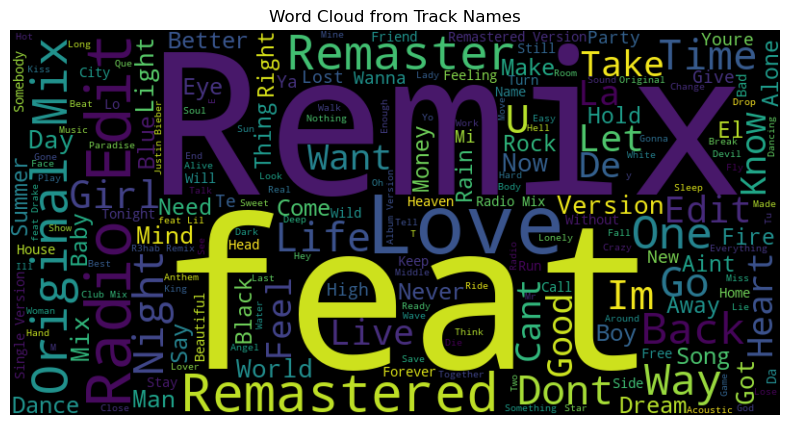

In [52]:
if 'track_name' in df_text.columns:
    text = df_text['track_name'].astype(str).str.cat(sep=' ')  # Convert to string and join

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Word Cloud from Track Names")
    plt.show()
else:
    print("Error: 'track_name' column not found in df_text.")

In [53]:
# creating new column - language by track_name

In [54]:
import pandas as pd
from langdetect import detect, DetectorFactory
from concurrent.futures import ThreadPoolExecutor

# Ensure consistent results
DetectorFactory.seed = 0  

# Function to detect language
def detect_language(text):
    try:
        return detect(text) if isinstance(text, str) and text.strip() else "unknown"
    except:
        return "unknown"


# Process only unique track names to avoid redundant work
unique_track_names = df_text['track_name'].dropna().unique()

# Use ThreadPoolExecutor (better for I/O tasks like `langdetect`)
track_name_dict = {}
with ThreadPoolExecutor() as executor:
    results = list(executor.map(detect_language, unique_track_names))

In [55]:
track_name_dict = dict(zip(unique_track_names, results))
df_text['track_language'] = df_text['track_name'].map(track_name_dict)

In [56]:
# Display results
language_counts = (df_text['track_language'].value_counts())
print(language_counts)

track_language
en         16564
de          2652
es          1335
it          1027
pt           955
tl           938
nl           836
fr           817
id           786
ca           669
af           616
so           510
ro           503
sw           501
no           490
da           438
cy           386
pl           376
fi           357
et           297
tr           260
unknown      256
sv           246
sl           200
vi           157
lt           153
hr           141
sk           103
sq            94
hu            75
cs            58
lv            32
Name: count, dtype: int64


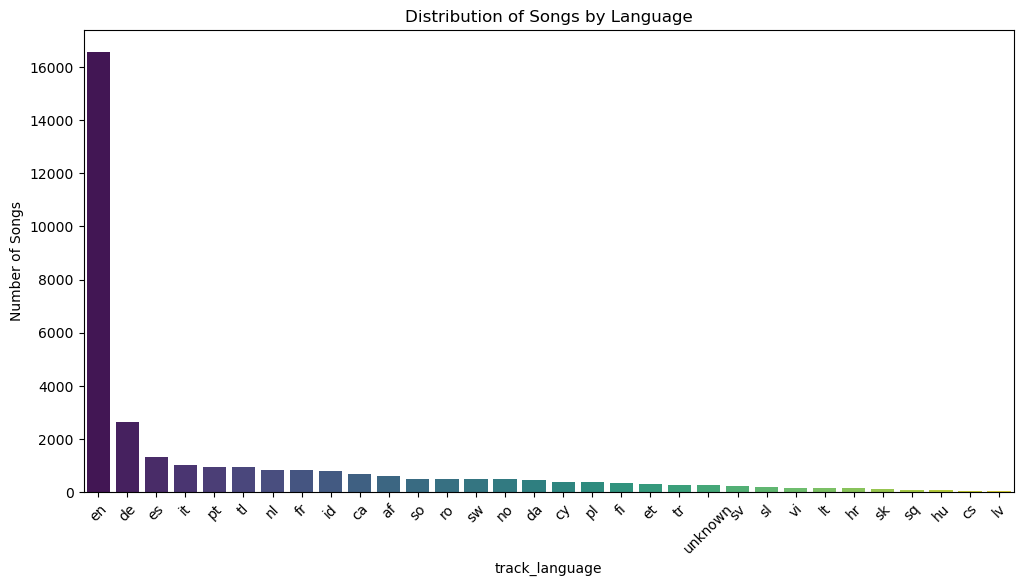

In [57]:
# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(x=language_counts.index, y=language_counts.values, palette="viridis")

# Customize the plot
plt.xlabel("track_language")
plt.ylabel("Number of Songs")
plt.title("Distribution of Songs by Language")
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()

In [58]:
# Split into "English" and "Not English"
df['language_category'] = df_text['track_language'].apply(lambda x: "English" if x == "en" else "Not English")

# Display counts
print(df['language_category'].value_counts())


language_category
English        16564
Not English    16269
Name: count, dtype: int64


In [59]:
#df.info()  checking 

### Translation of Track Names to English

In [60]:

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Define stopwords (multi-language)
available_languages = stopwords.fileids()
multi_language_stopwords = set(word for lang in available_languages for word in stopwords.words(lang))

# Custom stopwords
custom_stopwords = {"remix", "mix", "version", "edit", "feat", "radio", "extended", "the", "and"}
stop_words = multi_language_stopwords | custom_stopwords

# Function to clean text
def clean_text(text):
    if pd.isna(text):
        return []
    
    text = text.lower().replace("’s", "").replace("'", "")  # Normalize apostrophes
    words = word_tokenize(text)
    return [word for word in words if word.isalpha() and word not in stop_words]

                 track_id                                         track_name  \
0  6f807x0ima9a1j3vpbc7vn  I Dont Care with Justin Bieber  Loud Luxury Remix   
1  0r7cvbztwzgbtcydfa2p31                     Memories  Dillon Francis Remix   
2  1z1hg7vb0ahhdiemnde79l                     All the Time  Don Diablo Remix   
3  75fpbthrwqmzhlbjlugdc7                   Call You Mine  Keanu Silva Remix   
4  1e8pafckuyokkxphrhqw4x             Someone You Loved  Future Humans Remix   

                                   track_album_name playlist_name  \
0  I Dont Care with Justin Bieber Loud Luxury Remix     Pop Remix   
1                     Memories Dillon Francis Remix     Pop Remix   
2                     All the Time Don Diablo Remix     Pop Remix   
3                        Call You Mine  The Remixes     Pop Remix   
4             Someone You Loved Future Humans Remix     Pop Remix   

  track_language                                 track_name_english  
0             en  I Dont Care with

In [ ]:
TOP 5 WORDS 'TRACK NAME' without stopwords

In [66]:

# Function to clean text (assuming clean_text is defined elsewhere)
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return []  # Return an empty list for missing or invalid values
    words = text.lower().split()  # Simple example; modify based on your needs
    return words

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Apply text cleaning
df_text["cleaned_words"] = df_text["track_name"].astype(str).map(clean_text)

# Prepare data for batch translation
unique_texts = df_text["cleaned_words"].apply(lambda words: " ".join(words)).unique()

# Translate only unique texts in bulk
translator = GoogleTranslator(source="auto", target="en")
translation_dict = {text: translator.translate(text) for text in unique_texts if text.strip()}

# Apply translations to the DataFrame
df_text["track_name_english"] = df_text["cleaned_words"].apply(lambda words: translation_dict.get(" ".join(words), ""))

# Word frequency analysis
all_words = list(chain.from_iterable(df_text["cleaned_words"]))
word_counts = Counter(all_words)
top_5_words = [word for word, _ in word_counts.most_common(5)]

# Create new columns for each of the top 5 words
for word in top_5_words:
    df_text[word] = df_text["cleaned_words"].apply(lambda words: int(word in words))

# Display updated DataFrame
print(df_text.head())


                 track_id                                         track_name  \
0  6f807x0ima9a1j3vpbc7vn  I Dont Care with Justin Bieber  Loud Luxury Remix   
1  0r7cvbztwzgbtcydfa2p31                     Memories  Dillon Francis Remix   
2  1z1hg7vb0ahhdiemnde79l                     All the Time  Don Diablo Remix   
3  75fpbthrwqmzhlbjlugdc7                   Call You Mine  Keanu Silva Remix   
4  1e8pafckuyokkxphrhqw4x             Someone You Loved  Future Humans Remix   

                                   track_album_name playlist_name  \
0  I Dont Care with Justin Bieber Loud Luxury Remix     Pop Remix   
1                     Memories Dillon Francis Remix     Pop Remix   
2                     All the Time Don Diablo Remix     Pop Remix   
3                        Call You Mine  The Remixes     Pop Remix   
4             Someone You Loved Future Humans Remix     Pop Remix   

                                       cleaned_words  \
0  [i, dont, care, with, justin, bieber, loud, l

In [ ]:
# Get all available stopwords from NLTK
available_languages = stopwords.fileids()

# Collect stopwords for multiple languages
multi_language_stopwords = set()
for lang in available_languages:
    multi_language_stopwords.update(stopwords.words(lang))

# Add custom stopwords (common words in track names)
custom_stopwords = {
    "remix", "mix", "version", "edit", "feat", "radio", 
    "extended", "the", "and"
}

# Combine all stopwords
stop_words = multi_language_stopwords | custom_stopwords


# Tokenize and remove stopwords
df["filtered_words"] = (
    df["track_name_english"]
    .str.lower()
    .str.split()
    .apply(lambda words: [word for word in words if word not in stop_words])
)

# Expand words into separate columns
max_words = df["filtered_words"].apply(len).max()
df_word_columns = df["filtered_words"].apply(lambda x: x + [""] * (max_words - len(x)))  # Pad with empty strings
df_word_columns = pd.DataFrame(df_word_columns.tolist(), columns=[f"word_{i+1}" for i in range(max_words)])

# Concatenate the original DataFrame with new word columns
df = pd.concat([df, df_word_columns], axis=1).drop(columns=["filtered_words"])

# Flatten word lists and count frequency
all_words = df_word_columns.values.flatten()
all_words = [word for word in all_words if word]  # Remove empty strings

word_counts = Counter(all_words)
total_words = sum(word_counts.values())

# Calculate percentage of each word
word_percentages = [(word, count, (count / total_words) * 100) for word, count in word_counts.items()]
word_percentages_df = pd.DataFrame(word_percentages, columns=["Word", "Count", "Percentage"])

# Create an interactive bar chart using Plotly
fig = px.bar(
    word_percentages_df,
    x="Word",
    y="Percentage",
    title="Word Frequency as Percentage of Total Words in Track Names",
    text="Percentage",
    labels={"Word": "Word", "Percentage": "Percentage (%)"},
    color="Percentage",
    color_continuous_scale="Blues"
)

# Show chart
fig.show()

# Display final DataFrame with separate word columns
print(df)


In [ ]:
df = df.merge(df_text[['id', 'track_name_english']], left_on='track_id', right_on='id', how='left')

# Drop the extra 'id' column after merging (optional)
df.drop(columns=['id'], inplace=True)

In [61]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure stopwords and tokenizer are downloaded
nltk.download("stopwords")
nltk.download("punkt")

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Function to clean track names by removing stopwords
def remove_stopwords(text):
    if not isinstance(text, str):
        return ""  # Return empty string for missing values
    words = word_tokenize(text.lower())  # Tokenize words
    filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
    return " ".join(filtered_words)

# Apply stopword removal
df_text["track_name_cleaned"] = df_text["track_name_english"].apply(remove_stopwords)

# Display updated DataFrame
print(df_text[["track_name_english", "track_name_cleaned"]].head())
df_text["track_name_cleaned"]

[nltk_data] Downloading package stopwords to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


                                  track_name_english  \
0  I Dont Care with Justin Bieber  Loud Luxury Remix   
1                     Memories  Dillon Francis Remix   
2                     All the Time  Don Diablo Remix   
3                   Call You Mine  Keanu Silva Remix   
4             Someone You Loved  Future Humans Remix   

                          track_name_cleaned  
0  dont care justin bieber loud luxury remix  
1              memories dillon francis remix  
2                          time diablo remix  
3                call mine keanu silva remix  
4          someone loved future humans remix  


0        dont care justin bieber loud luxury remix
1                    memories dillon francis remix
2                                time diablo remix
3                      call mine keanu silva remix
4                someone loved future humans remix
                           ...                    
32828              city lights official radio edit
32829              closer sultan ned shepard remix
32830                   sweet surrender radio edit
32831                              maor levi remix
32832                         typhoon original mix
Name: track_name_cleaned, Length: 32833, dtype: object

In [62]:

# Define stopwords
custom_stopwords = {"remix", "mix", "version", "edit", "feat", "radio", "extended", "the", "and"}

# Function to remove stopwords
def remove_custom_stopwords(text):
    if isinstance(text, str):  # Ensure text is a string
        return " ".join(word for word in text.split() if word.lower() not in custom_stopwords)
    return text  # Return as-is if not a string

# Apply function to DataFrame column
df_text["track_name_cleaned"] = df_text["track_name_cleaned"].apply(remove_custom_stopwords)


In [63]:
#df_text["track_name_cleaned"].head()  --cheking

In [64]:
# Function to clean text (assuming clean_text is defined elsewhere)

#Cleans track names.

#Translates non-English track names to English.

#Performs word frequency analysis and adds top words as features.

In [ ]:

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Define stopwords (multi-language)
available_languages = stopwords.fileids()
multi_language_stopwords = set(word for lang in available_languages for word in stopwords.words(lang))

# Custom stopwords
custom_stopwords = {"remix", "mix", "version", "edit", "feat", "radio", "extended", "the", "and"}
stop_words = multi_language_stopwords | custom_stopwords

# Function to clean text
def clean_text(text):
    if pd.isna(text):
        return []
    
    text = text.lower().replace("’s", "").replace("'", "")  # Normalize apostrophes
    words = word_tokenize(text)
    return [word for word in words if word.isalpha() and word not in stop_words]

In [65]:
import pandas as pd
from deep_translator import GoogleTranslator


if "cleaned_text" not in df_text.columns:
    df_text["cleaned_text"] = df_text["cleaned_words"].apply(lambda words: " ".join(words))

unique_texts = df_text["cleaned_text"].unique().tolist()  # Convert to a list

# Function to batch translate with explicit list conversion
def batch_translate(text_list, batch_size=50):
    translator = GoogleTranslator(source="auto", target="en")
    translations = {}

    for i in range(0, len(text_list), batch_size):
        batch = list(text_list[i : i + batch_size])  # Ensure it's a Python list
        translated_batch = translator.translate_batch(batch)
        translations.update(dict(zip(batch, translated_batch)))
    
    return translations

KeyError: 'cleaned_words'

In [ ]:
# Perform translation
translation_dict = batch_translate(unique_texts)

# Apply translations
df_text["track_name_english"] = df_text["cleaned_text"].map(translation_dict)

print(df_text.head())


In [ ]:
# Create new columns for each of the top 5 words
for word in top_5_words:
    df_text[word] = df_text["cleaned_words"].apply(lambda words: int(word in words))

# Display updated DataFrame
print(df_text.head())

In [ ]:
# merge function in pandas to move track_name_english from df_text to df

In [ ]:
df = df.merge(df_text[['id', 'track_name_english']], left_on='track_id', right_on='id', how='left')

# Drop the extra 'id' column after merging (optional)
df.drop(columns=['id'], inplace=True)

In [ ]:
#df.info()

In [ ]:
# Top 5 Most Frequent Words in 'track_name_english' Column, first stopwords-> lowercase

In [ ]:
#Removes stopwords from track names.

#Expands track names into separate word columns.

#Analyzes word frequency as a percentage of total words.

#Visualizes word distribution using Plotly.

In [ ]:
# Get all available stopwords from NLTK
available_languages = stopwords.fileids()

# Collect stopwords for multiple languages
multi_language_stopwords = set()
for lang in available_languages:
    multi_language_stopwords.update(stopwords.words(lang))

# Add custom stopwords (common words in track names)
custom_stopwords = {
    "remix", "mix", "version", "edit", "feat", "radio", 
    "extended", "the", "and"
}

# Combine all stopwords
stop_words = multi_language_stopwords | custom_stopwords


# Tokenize and remove stopwords
df["filtered_words"] = (
    df["track_name_english"]
    .str.lower()
    .str.split()
    .apply(lambda words: [word for word in words if word not in stop_words])
)

# Expand words into separate columns
max_words = df["filtered_words"].apply(len).max()
df_word_columns = df["filtered_words"].apply(lambda x: x + [""] * (max_words - len(x)))  # Pad with empty strings
df_word_columns = pd.DataFrame(df_word_columns.tolist(), columns=[f"word_{i+1}" for i in range(max_words)])

# Concatenate the original DataFrame with new word columns
df = pd.concat([df, df_word_columns], axis=1).drop(columns=["filtered_words"])

# Flatten word lists and count frequency
all_words = df_word_columns.values.flatten()
all_words = [word for word in all_words if word]  # Remove empty strings

word_counts = Counter(all_words)
total_words = sum(word_counts.values())

# Calculate percentage of each word
word_percentages = [(word, count, (count / total_words) * 100) for word, count in word_counts.items()]
word_percentages_df = pd.DataFrame(word_percentages, columns=["Word", "Count", "Percentage"])

# Create an interactive bar chart using Plotly
fig = px.bar(
    word_percentages_df,
    x="Word",
    y="Percentage",
    title="Word Frequency as Percentage of Total Words in Track Names",
    text="Percentage",
    labels={"Word": "Word", "Percentage": "Percentage (%)"},
    color="Percentage",
    color_continuous_scale="Blues"
)

# Show chart
fig.show()

# Display final DataFrame with separate word columns
print(df)


In [ ]:
# Ensure track_name is a string
df['track_name'] = df['track_name'].astype(str)

# Tokenize words from track names
all_words = " ".join(df['track_name']).split()

# Count word frequencies
word_counts = Counter(all_words)

# Get the top 5 most common words
top_5_words = [word for word, _ in word_counts.most_common(5)]

# Create new columns for each of the top 5 words
for word in top_5_words:
    df[word] = df['track_name'].apply(lambda x: 1 if word in x.split() else 0)

# Display the updated DataFrame
print(df.head())

In [ ]:
# artist_type

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import names

# Download NLTK name corpus if not available
nltk.download('names')

# Load male and female names from NLTK corpus
male_names = set(names.words('male.txt'))
female_names = set(names.words('female.txt'))

# Keywords indicating a band
band_keywords = ["band", "orchestra", "quartet", "group", "ensemble", "choir", "collective", "crew"]

# Function to classify artist type
def classify_artist(artist_name):
    artist_name_lower = artist_name.lower()

    # Check if the artist is a band
    if any(keyword in artist_name_lower for keyword in band_keywords) or "&" in artist_name or " and " in artist_name_lower:
        return "Band"

    # Extract the first word as the assumed first name
    first_name = artist_name.split()[0].capitalize()

    # Classify as Female if the first name matches female names
    if first_name in female_names:
        return "Female"

    # Classify as Male if the first name matches male names
    if first_name in male_names:
        return "Male"

    # Default to Male if unknown (assumption: more male artists exist in the dataset)
    return "Male"



# Apply classification
df['track_artist_type'] = df['track_artist'].apply(classify_artist)

# Display results
print(df)


In [ ]:
# track_sentiment

In [ ]:

# Download VADER lexicon (only once)
nltk.download("vader_lexicon")

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Sample DataFrame (Replace this with your dataset)
df = df["track_name_english"]

# Function to compute sentiment score
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return "neutral"  # If the text is empty or NaN, return neutral
    sentiment_score = sia.polarity_scores(text)["compound"]
    if sentiment_score >= 0.05:
        return "positive"
    elif sentiment_score <= -0.05:
        return "negative"
    else:
        return "neutral"

# Apply sentiment analysis to the 'track_name' column
df["track_sentiment"] = df_text['track_name'].apply(get_sentiment)

# Display results
print(df)


In [ ]:
#find type track by name:  "remix", "acoustic", "live", "mix", "edit", "version"

In [ ]:
# Sample DataFrame
df =  df["track_name_english"]

# Define custom words to find in track names
custom_words = {"remix", "acoustic", "live", "mix", "edit", "version"}

# Function to find custom words in a track name
def find_custom_words(track_name):
    if pd.isna(track_name):
        return None
    words = set(track_name.lower().split())  # Convert to lowercase and split into words
    matched_words = words.intersection(custom_words)  # Find matching words
    return ", ".join(matched_words) if matched_words else None  # Join matches or return None

# Apply the function to detect custom words in track names
df["custom_words_found"] = df["track_name_english"].apply(find_custom_words)

# Display results
print(df)


In [ ]:
# new colmn - artist_popularity

In [ ]:
# Load the CSV file
tracks_df = pd.read_csv(r"C:\Users\Meital atar\Documents\DATA_SCIENCE\ML_PROJECT_spotify_songs\Kaggel_files\artists.csv")

# Merge on 'artist_id' and keep the 'popularity' column
df_merge = df.merge(tracks_df[['id', 'popularity']], on='artist_id', how='left')

# Display the first few rows to verify
print(df_merge.head())



In [ ]:
 # explicit (0 = No explicit content, 1 = Explicit content)

In [ ]:
# Load datasets
#tracks_df = pd.read_csv(r"C:\Users\Meital atar\Documents\DATA_SCIENCE\ML_PROJECT_spotify_songs\Kaggel_files\tracks.csv")

# Ensure 'track_id' and 'id' columns exist
if 'track_id' in df.columns and 'id' in tracks_df.columns:
    # Merge on 'track_id' and keep the 'explicit' column
    df_merge = df.merge(tracks_df[['id', 'explicit']], left_on='track_id', right_on='id', how='left')

    # Display result
    print(df_merge.head())
else:
    print("Columns 'track_id' or 'id' are missing!")


In [ ]:
df.info()

In [ ]:
df.to_csv('df_after_feature_eng.csv')
df.to_pickle ('df_after_feature_eng.pkl')